# Inspect T-sweep grid outputs

Loads finished multi-`T` jobsub campaigns (`out_*.tgz`), unpacks to `DATA_ROOT`, and plots:

1. **Per-patch T panels** — original / diffused / reco / saliency across T
2. **Healthy vs coh** side-by-side at each T
3. **Score vs T** — noise-region residual RMS (aggregate + a few patches)

**Kernel:** CPU only (no CUDA). Defaults to the anisotropic@20k stop-signal sweep
`T ∈ {200,400,600,800,1000}`.

Defaults pin the **original** finished campaigns
(`…222514…healthy…` / `…222538…coh…`), not the later diffused resubmit.

Related: `03_InspectGridOutputs.ipynb` (single-T), `train/03_LearningCurves.ipynb` (Find stop signal).


In [17]:
from __future__ import annotations

import importlib
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

import configs.paths as _paths_mod
import train.stop_signal_eval as stop_eval

importlib.reload(_paths_mod)
importlib.reload(stop_eval)
from configs.paths import DATA_ROOT  # noqa: E402

PNFS_OUT = Path("/pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference")
UNPACK_ROOT = DATA_ROOT / "inference" / "grid_unpacked" / "tsweep"
FIG_DIR = DATA_ROOT / "figures" / "tsweep"
UNPACK_ROOT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Configure: original anisotropic@20k stop-signal T-sweep (not the diffused resubmit) ---
T_TAG = "200-400-600-800-1000"
MODE = "ddim2ddim"
CONFIG = "anisotropic"
STEP = 20000

# Pin to the first finished campaigns (10/12 coh tarballs; healthy complete).
HEALTHY_CAMPAIGN = PNFS_OUT / (
    "2026_09_15_222514__stopsignal_healthy_anisotropic_ckpt020000_T200-400-600-800-1000"
)
COH_CAMPAIGN = PNFS_OUT / (
    "2026_09_15_222538__stopsignal_anisotropic_ckpt020000_T200-400-600-800-1000"
)

# Which probes to load/plot. For coh-only T-sweep inspection use ("coh",).
PROBES = ("healthy", "coh")

N_PATCH_EXAMPLES = 3  # how many stems to panel-plot
SCORE_KIND = "noise_rms"

print("DATA_ROOT", DATA_ROOT)
print("UNPACK_ROOT", UNPACK_ROOT)
print("FIG_DIR", FIG_DIR)
print("COH_CAMPAIGN", COH_CAMPAIGN.name)
print("PROBES", PROBES)
print("numpy", np.__version__)


DATA_ROOT /exp/sbnd/data/users/munjung/anomaly-detection
UNPACK_ROOT /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/tsweep
FIG_DIR /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep
COH_CAMPAIGN 2026_09_15_222538__stopsignal_anisotropic_ckpt020000_T200-400-600-800-1000
PROBES ('healthy', 'coh')
numpy 1.23.5


## Discover / unpack campaigns

In [18]:
def resolve_campaign(explicit: Path | None, *, probe: str) -> Path:
    if explicit is not None and explicit.is_dir() and any(explicit.glob("out_*.tgz")):
        return explicit
    camps = stop_eval.discover_stopsignal_campaigns(
        PNFS_OUT, configs=(CONFIG,), probes=(probe,), require_tgz=True
    )
    matches = [
        c for c in camps if c.step == STEP and c.t_tag == T_TAG and c.config == CONFIG
    ]
    if not matches:
        raise FileNotFoundError(
            f"No {probe} campaign for {CONFIG}@{STEP} T={T_TAG} under {PNFS_OUT}"
        )
    # Prefer most complete; on tie prefer earlier stamp (original over diffused resubmit).
    best = sorted(matches, key=lambda c: (-c.n_tgz, c.stamp))[0]
    print(f"auto-picked {probe}: {best.path.name} (n_tgz={best.n_tgz})")
    return best.path


_explicit = {"healthy": HEALTHY_CAMPAIGN, "coh": COH_CAMPAIGN}
campaigns = {probe: resolve_campaign(_explicit.get(probe), probe=probe) for probe in PROBES}
unpacked: dict[str, Path] = {}
for probe, camp in campaigns.items():
    n_tgz = len(list(camp.glob("out_*.tgz")))
    dest = stop_eval.unpack_campaign(camp, UNPACK_ROOT)
    n_arr = len(list(dest.rglob("*_arrays.npz")))
    unpacked[probe] = dest
    print(f"{probe:8s}: {camp.name}")
    print(f"          tgz={n_tgz}  arrays.npz={n_arr}  → {dest}")

_TS_RE = re.compile(rf"_T(\d+)_{re.escape(MODE)}_arrays\.npz$")
TS = sorted(
    {
        int(m.group(1))
        for dest in unpacked.values()
        for p in dest.rglob(f"*_{MODE}_arrays.npz")
        if (m := _TS_RE.search(p.name))
    }
)
print("T values found:", TS)


healthy : 2026_09_15_222514__stopsignal_healthy_anisotropic_ckpt020000_T200-400-600-800-1000
          tgz=12  arrays.npz=180  → /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/tsweep/2026_09_15_222514__stopsignal_healthy_anisotropic_ckpt020000_T200-400-600-800-1000
coh     : 2026_09_15_222538__stopsignal_anisotropic_ckpt020000_T200-400-600-800-1000
          tgz=10  arrays.npz=150  → /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/tsweep/2026_09_15_222538__stopsignal_anisotropic_ckpt020000_T200-400-600-800-1000
T values found: [200, 400, 600, 800, 1000]


## Index patches by stem × T

In [19]:
def stem_from_arrays_name(name: str, T: int, mode: str = MODE) -> str:
    # <stem>_T{T}_{mode}_arrays.npz
    suf = f"_T{T}_{mode}_arrays.npz"
    if name.endswith(suf):
        return name[: -len(suf)]
    return Path(name).stem


def index_probe(dest: Path) -> dict[str, dict[int, Path]]:
    """stem → {T → arrays.npz path}."""
    out: dict[str, dict[int, Path]] = defaultdict(dict)
    for T in TS:
        for fp in stop_eval.iter_arrays_npz(dest, T, MODE):
            stem = stem_from_arrays_name(fp.name, T)
            out[stem][T] = fp
    return dict(out)


index = {probe: index_probe(dest) for probe, dest in unpacked.items()}
for probe, by_stem in index.items():
    n_full = sum(1 for ts in by_stem.values() if len(ts) == len(TS))
    print(
        f"{probe:8s}: {len(by_stem)} stems, {n_full} with all T={TS}"
    )

shared_stems = sorted(set(index.get("healthy", {})) & set(index.get("coh", {})))
healthy_only = sorted(set(index.get("healthy", {})) - set(index.get("coh", {})))
coh_only = sorted(set(index.get("coh", {})) - set(index.get("healthy", {})))
print(f"shared stems (healthy∩coh): {len(shared_stems)}")
if shared_stems:
    print("  e.g.", shared_stems[0])
if coh_only:
    print(f"coh-only stems (incomplete healthy twin): {len(coh_only)}")

healthy : 36 stems, 36 with all T=[200, 400, 600, 800, 1000]
coh     : 30 stems, 30 with all T=[200, 400, 600, 800, 1000]
shared stems (healthy∩coh): 30
  e.g. 86414745_63_g4-raw-0_10.h5_7_f0_y0_x0


## Helpers: load arrays + score

In [20]:
def load_patch(fp: Path) -> dict[str, np.ndarray | str | None]:
    z = np.load(fp)
    def _squeeze(a):
        a = np.squeeze(a)
        return a[0] if a.ndim == 3 else a

    orig = _squeeze(z["original"])
    reco = _squeeze(z["reconstructed"])
    sal = _squeeze(z["saliency"]) if "saliency" in z.files else reco - orig
    diffused = _squeeze(z["diffused"]) if "diffused" in z.files else None
    fname = str(z["input_filename"]) if "input_filename" in z.files else fp.name
    return {
        "original": orig,
        "diffused": diffused,
        "reconstructed": reco,
        "saliency": sal,
        "name": Path(fname).name,
        "has_diffused": diffused is not None,
    }


def score_patch(fp: Path, kind: str = SCORE_KIND) -> float:
    scores, _, _ = stop_eval.score_arrays_file(fp, score_kind=kind)
    return float(np.mean(scores))


def load_T_stack(by_T: dict[int, Path]) -> dict[int, dict]:
    return {T: load_patch(fp) for T, fp in sorted(by_T.items())}


## Per-patch T panel (original / diffused / reco / saliency)

One figure per stem: rows = `{original, diffused, reconstructed, saliency}` when
`diffused` is present in `*_arrays.npz`; otherwise original / reco / saliency.
Columns = T.


example stems: ['86414745_63_g4-raw-0_10.h5_7_f0_y0_x0', '86414745_63_g4-raw-0_10.h5_7_f0_y0_x2', '86414745_63_g4-raw-0_10.h5_7_f0_y0_x3']


healthy — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x0: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_healthy_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x0.pdf


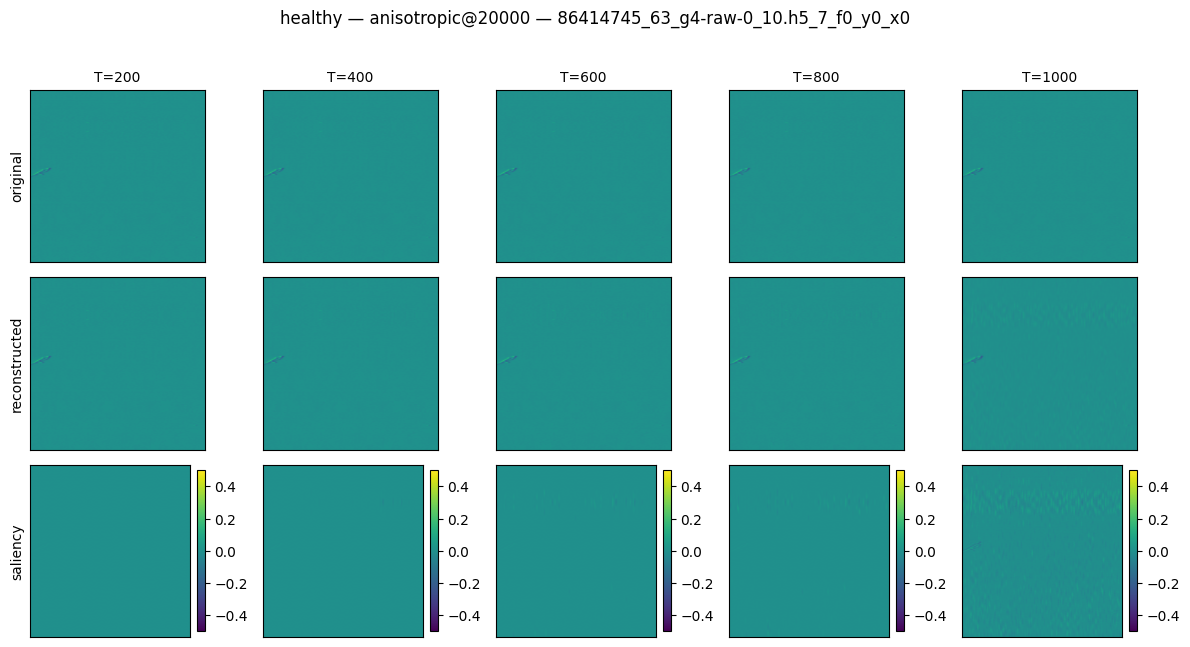

coh — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x0: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_coh_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x0.pdf


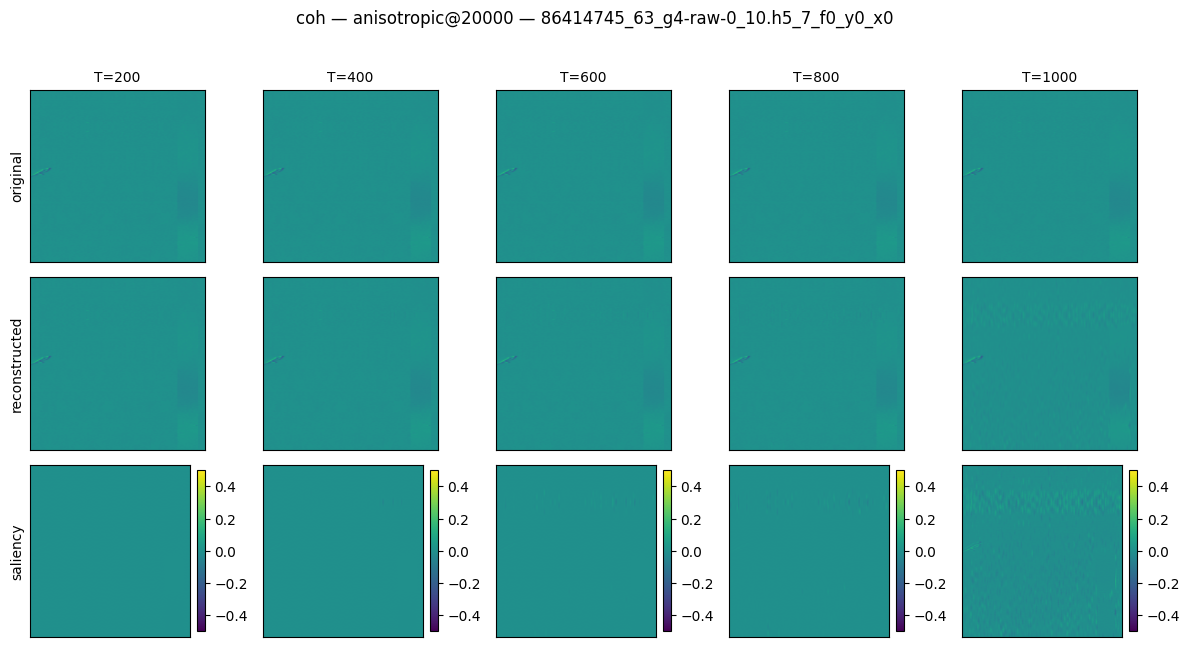

healthy — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x2: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_healthy_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x2.pdf


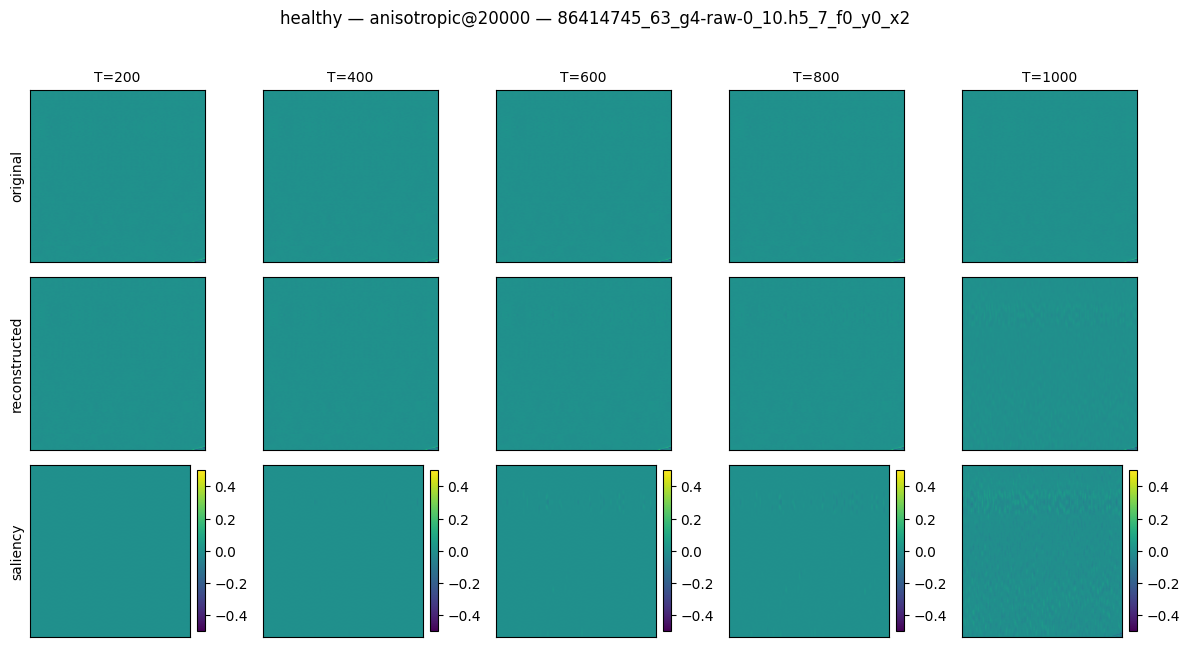

coh — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x2: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_coh_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x2.pdf


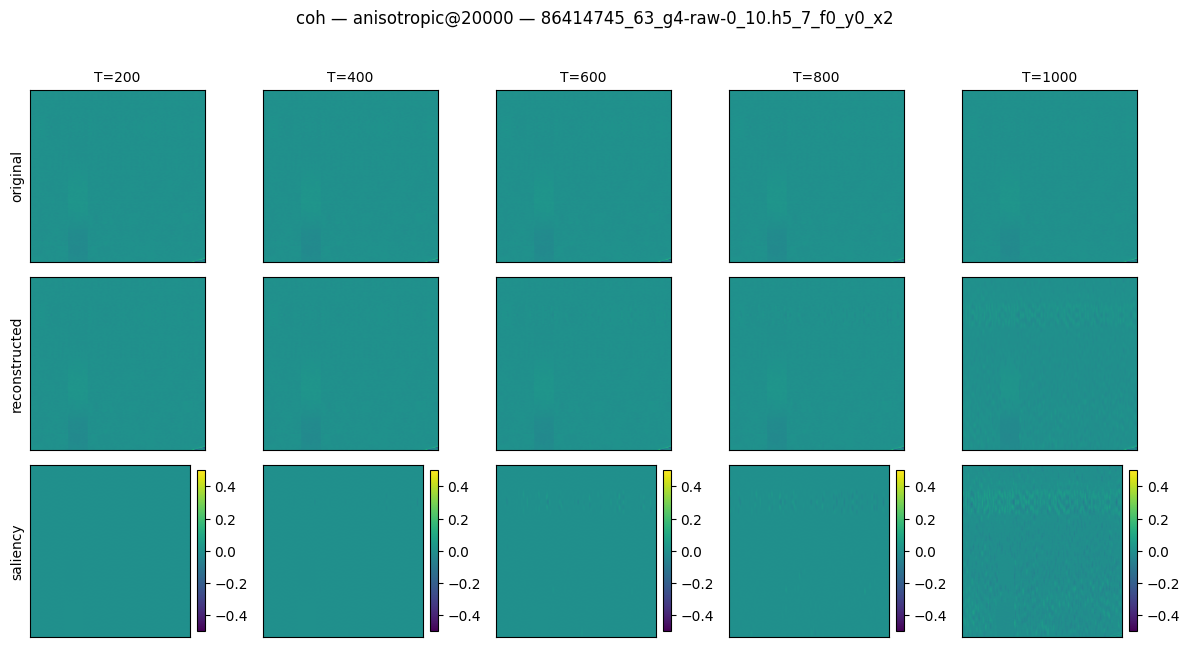

healthy — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x3: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_healthy_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x3.pdf


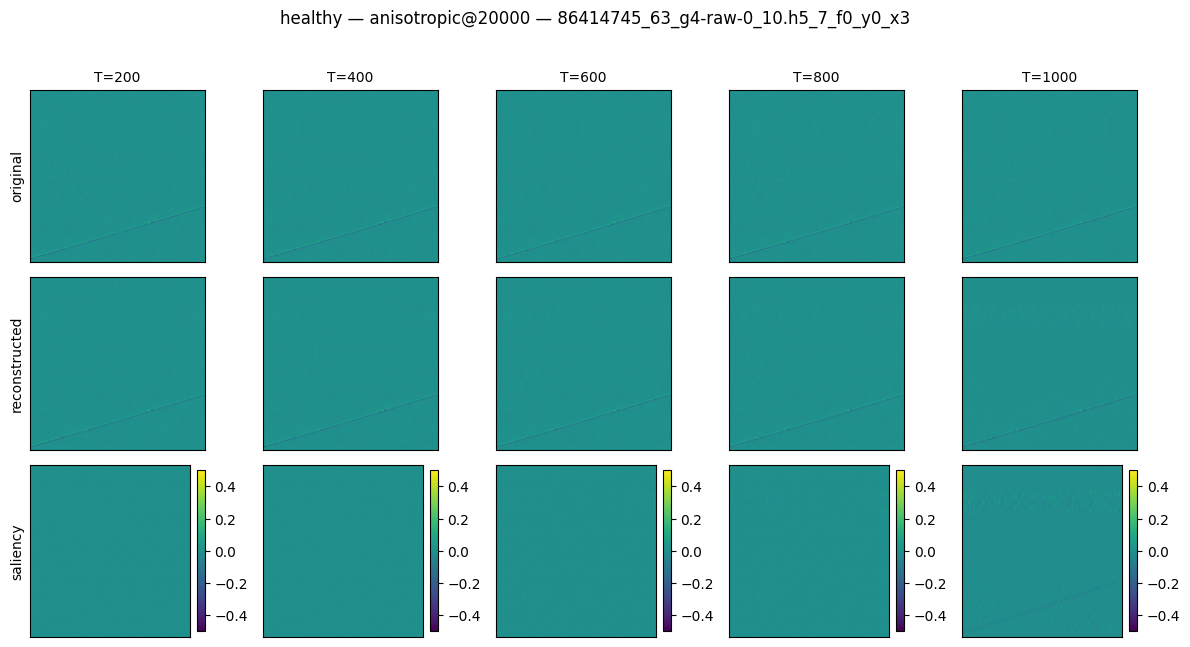

coh — anisotropic@20000 — 86414745_63_g4-raw-0_10.h5_7_f0_y0_x3: no `diffused` in arrays.npz (older jobs). Re-run T-sweep after inference save update to include it.
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/panel_coh_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x3.pdf


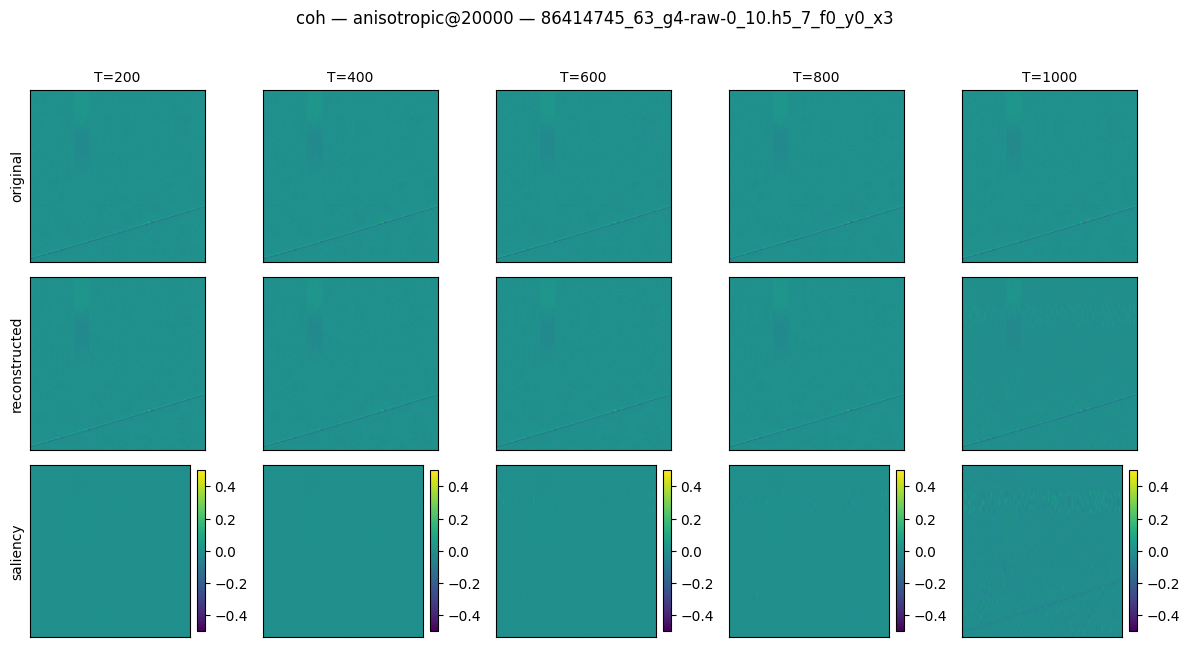

In [21]:
def plot_T_panel(
    by_T: dict[int, Path],
    *,
    title: str,
    out_pdf: Path | None = None,
    vmax_sal: float = 0.5,
) -> None:
    stack = load_T_stack(by_T)
    Ts_local = sorted(stack)
    if not Ts_local:
        print(f"{title}: empty")
        return
    has_diff = any(stack[T].get("has_diffused") for T in Ts_local)
    rows = (
        ("original", "reconstructed", "saliency")
        if not has_diff
        else ("original", "diffused", "reconstructed", "saliency")
    )
    if not has_diff:
        print(
            f"{title}: no `diffused` in arrays.npz "
            "(older jobs). Re-run T-sweep after inference save update to include it."
        )
    fig, axes = plt.subplots(
        len(rows), len(Ts_local), figsize=(2.4 * len(Ts_local), 2.1 * len(rows)), squeeze=False
    )
    for c, T in enumerate(Ts_local):
        patch = stack[T]
        for r, key in enumerate(rows):
            ax = axes[r, c]
            img = patch.get(key)
            if img is None:
                ax.set_axis_off()
                ax.set_title("missing" if r == 0 else "")
                continue
            if key == "saliency":
                vmin, vmax = -vmax_sal, vmax_sal
            else:
                vmin, vmax = -1.0, 1.0
            im = ax.imshow(img, aspect="auto", origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(f"T={T}", fontsize=10)
            if c == 0:
                ax.set_ylabel(key, fontsize=10)
            if key == "saliency":
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")
        print(f"saved {out_pdf}")
    plt.show()


# Prefer shared stems so healthy/coh panels use the same patch geometry
example_stems = (shared_stems or sorted(index.get("healthy", {})) or sorted(index.get("coh", {})))[
    :N_PATCH_EXAMPLES
]
print("example stems:", example_stems)

for stem in example_stems:
    for probe in PROBES:
        by_T = index.get(probe, {}).get(stem)
        if not by_T:
            print(f"skip {probe}/{stem}: missing")
            continue
        short = stem if len(stem) < 48 else stem[:45] + "..."
        plot_T_panel(
            by_T,
            title=f"{probe} — {CONFIG}@{STEP} — {short}",
            out_pdf=FIG_DIR / f"panel_{probe}_{CONFIG}_ckpt{STEP:06d}_{stem[:60]}.pdf",
        )


## Healthy vs coh side-by-side (saliency across T)

Same stem: top row healthy saliency, bottom row coh saliency.

saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/sal_compare_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x0.pdf


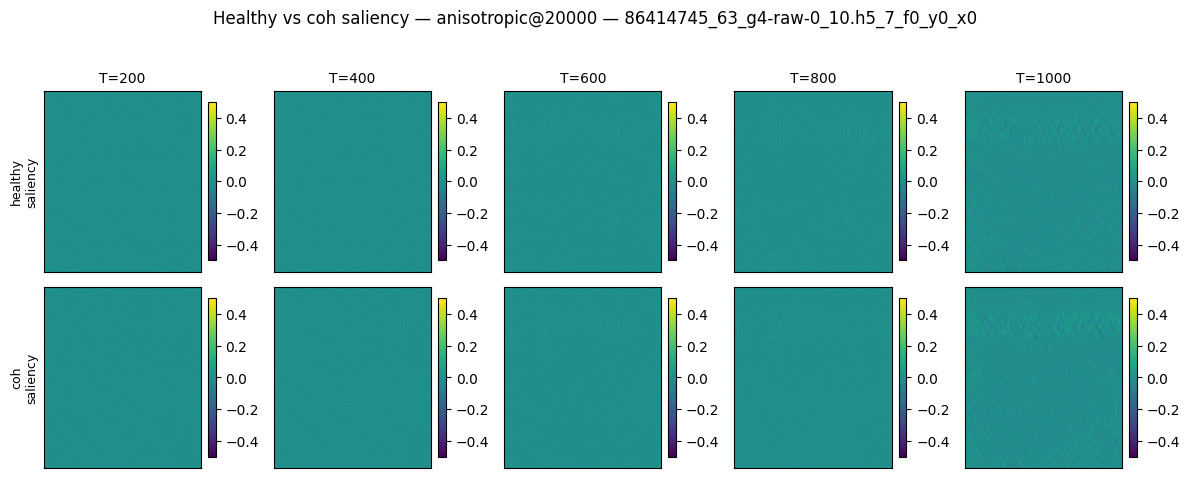

saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/sal_compare_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x2.pdf


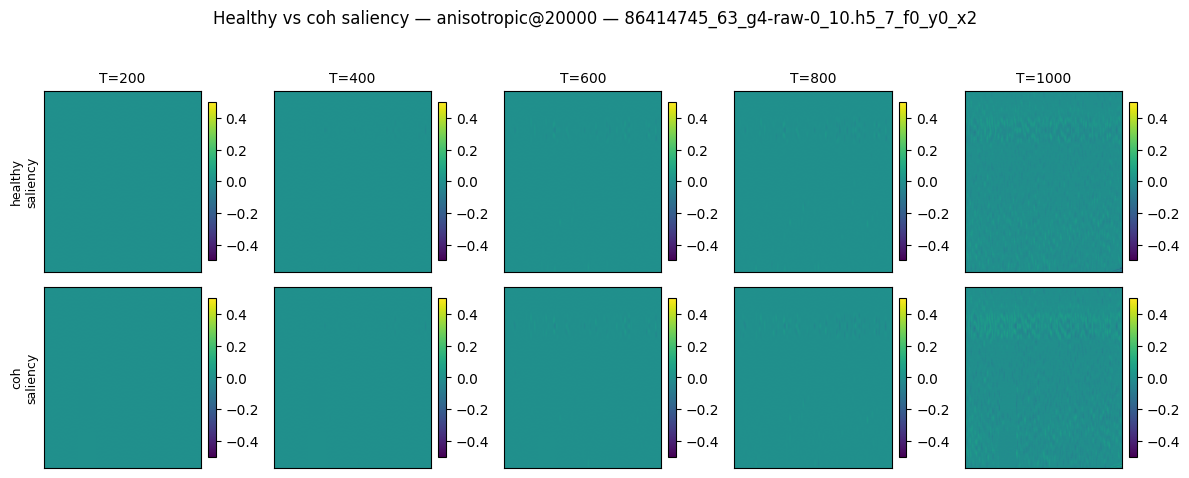

saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/sal_compare_anisotropic_ckpt020000_86414745_63_g4-raw-0_10.h5_7_f0_y0_x3.pdf


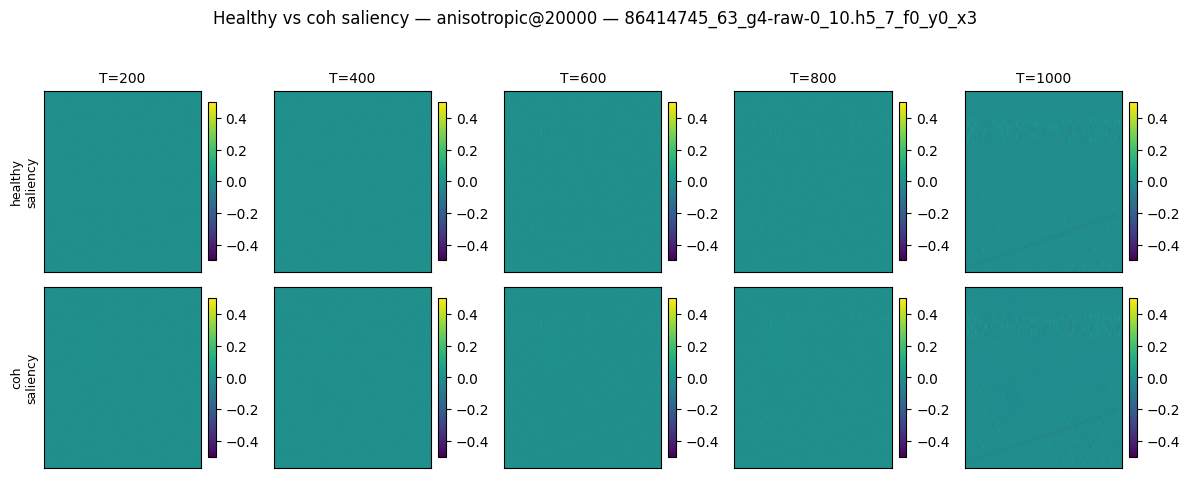

In [22]:
def plot_healthy_vs_coh_saliency(
    stem: str,
    *,
    vmax_sal: float = 0.5,
    out_pdf: Path | None = None,
) -> None:
    h = index.get("healthy", {}).get(stem)
    c = index.get("coh", {}).get(stem)
    if not h or not c:
        print(f"need both probes for {stem}")
        return
    Ts_local = sorted(set(h) & set(c))
    fig, axes = plt.subplots(2, len(Ts_local), figsize=(2.4 * len(Ts_local), 4.6), squeeze=False)
    for col, T in enumerate(Ts_local):
        for row, (probe, by_T) in enumerate((("healthy", h), ("coh", c))):
            sal = load_patch(by_T[T])["saliency"]
            ax = axes[row, col]
            im = ax.imshow(
                sal, aspect="auto", origin="lower", cmap="viridis", vmin=-vmax_sal, vmax=vmax_sal
            )
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(f"T={T}", fontsize=10)
            if col == 0:
                ax.set_ylabel(f"{probe}\nsaliency", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    short = stem if len(stem) < 52 else stem[:49] + "..."
    fig.suptitle(f"Healthy vs coh saliency — {CONFIG}@{STEP} — {short}", y=1.03)
    fig.tight_layout()
    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")
        print(f"saved {out_pdf}")
    plt.show()


if "healthy" not in PROBES or "coh" not in PROBES:
    print("Skipping healthy-vs-coh panel (need both probes in PROBES).")
else:
    for stem in example_stems:
        if stem not in shared_stems:
            continue
        plot_healthy_vs_coh_saliency(
            stem,
            out_pdf=FIG_DIR / f"sal_compare_{CONFIG}_ckpt{STEP:06d}_{stem[:60]}.pdf",
        )


## Score vs T

Noise-region residual RMS (`SCORE_KIND`) mean ± std over available stems, plus a few individual stems.

saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/score_vs_T_anisotropic_ckpt020000_noise_rms.pdf


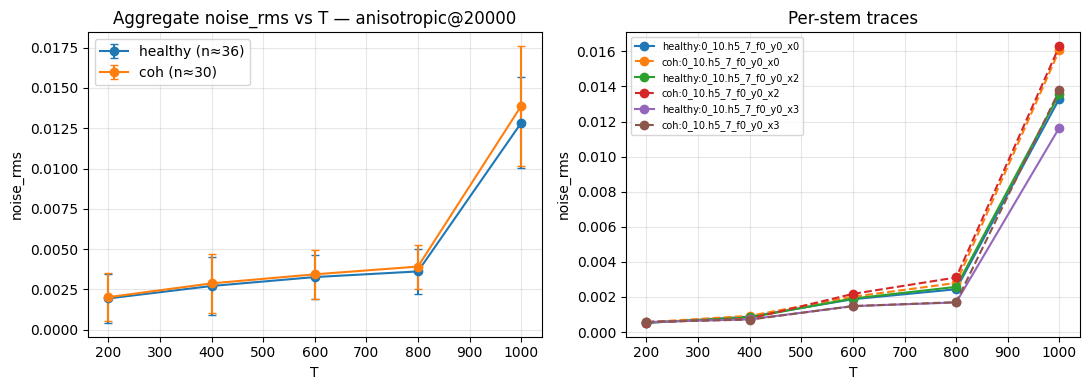


=== mean scores ===
healthy  T= 200: mean=0.00194513  std=0.00151652  n=36
healthy  T= 400: mean=0.00271731  std=0.0017891  n=36
healthy  T= 600: mean=0.00327094  std=0.00138892  n=36
healthy  T= 800: mean=0.00362063  std=0.00137428  n=36
healthy  T=1000: mean=0.0128333  std=0.00281834  n=36
coh      T= 200: mean=0.00202311  std=0.00150261  n=30
coh      T= 400: mean=0.00287965  std=0.00181507  n=30
coh      T= 600: mean=0.00344136  std=0.00150591  n=30
coh      T= 800: mean=0.00392125  std=0.00136742  n=30
coh      T=1000: mean=0.013882  std=0.0037128  n=30


In [23]:
def scores_by_T(by_stem: dict[str, dict[int, Path]]) -> dict[int, list[float]]:
    out: dict[int, list[float]] = defaultdict(list)
    for stem, by_T in by_stem.items():
        for T, fp in by_T.items():
            try:
                out[T].append(score_patch(fp))
            except Exception as exc:  # noqa: BLE001
                print(f"score fail {stem} T={T}: {exc}")
    return dict(out)


score_tables = {probe: scores_by_T(by_stem) for probe, by_stem in index.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Aggregate
ax = axes[0]
for probe, tab in score_tables.items():
    Ts_p = sorted(tab)
    means = [float(np.mean(tab[T])) for T in Ts_p]
    stds = [float(np.std(tab[T])) for T in Ts_p]
    ax.errorbar(Ts_p, means, yerr=stds, marker="o", capsize=3, label=f"{probe} (n≈{len(tab[Ts_p[0]]) if Ts_p else 0})")
ax.set_xlabel("T")
ax.set_ylabel(SCORE_KIND)
ax.set_title(f"Aggregate {SCORE_KIND} vs T — {CONFIG}@{STEP}")
ax.grid(True, alpha=0.3)
ax.legend()

# Per-stem traces (shared)
ax = axes[1]
for stem in example_stems[: min(3, len(example_stems))]:
    for probe, style in (("healthy", "-"), ("coh", "--")):
        by_T = index.get(probe, {}).get(stem)
        if not by_T:
            continue
        Ts_p = sorted(by_T)
        ys = [score_patch(by_T[T]) for T in Ts_p]
        ax.plot(Ts_p, ys, style, marker="o", label=f"{probe}:{stem[-18:]}")
ax.set_xlabel("T")
ax.set_ylabel(SCORE_KIND)
ax.set_title("Per-stem traces")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

fig.tight_layout()
out = FIG_DIR / f"score_vs_T_{CONFIG}_ckpt{STEP:06d}_{SCORE_KIND}.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

print("\n=== mean scores ===")
for probe, tab in score_tables.items():
    for T in sorted(tab):
        print(
            f"{probe:8s} T={T:4d}: mean={np.mean(tab[T]):.6g}  std={np.std(tab[T]):.6g}  n={len(tab[T])}"
        )

## Optional: AUC vs T (needs overlapping healthy + coh stems)

T=200: n=30 AUC=0.5499999999999999 hlthy=0.0019905459570289056 anom=0.0020231116440232004
T=400: n=30 AUC=0.5333333333333333 hlthy=0.0027821885670155323 anom=0.0028796482894055497
T=600: n=30 AUC=0.5622222222222223 hlthy=0.0032994551221512103 anom=0.003441358448193126
T=800: n=30 AUC=0.5688888888888889 hlthy=0.0036627337032408276 anom=0.003921253128190687
T=1000: n=30 AUC=0.5966666666666668 hlthy=0.012699086989006273 anom=0.01388200835871523
saved /exp/sbnd/data/users/munjung/anomaly-detection/figures/tsweep/auc_vs_T_anisotropic_ckpt020000_noise_rms.pdf


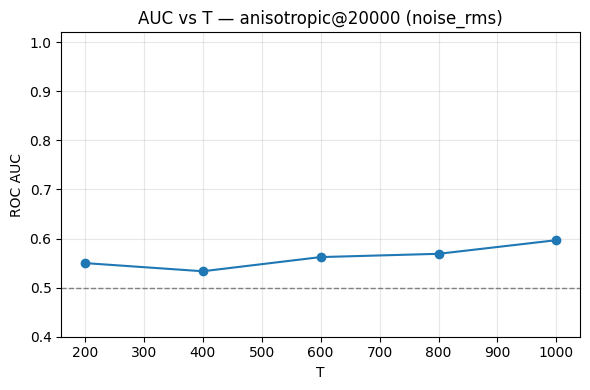

In [24]:
if not shared_stems:
    print("No shared stems — skip AUC vs T (coh campaign may be incomplete).")
else:
    auc_rows = []
    for T in TS:
        h_scores, a_scores = [], []
        for stem in shared_stems:
            hp = index["healthy"].get(stem, {}).get(T)
            ap = index["coh"].get(stem, {}).get(T)
            if hp is None or ap is None:
                continue
            h_scores.append(score_patch(hp))
            a_scores.append(score_patch(ap))
        metrics = stop_eval.roc_auc_youden(
            np.asarray(h_scores, dtype=float), np.asarray(a_scores, dtype=float)
        )
        auc_rows.append(
            {
                "T": T,
                "n": len(h_scores),
                "auc": metrics["auc"],
                "healthy_mean": float(np.mean(h_scores)) if h_scores else None,
                "anomaly_mean": float(np.mean(a_scores)) if a_scores else None,
            }
        )
        print(
            f"T={T}: n={len(h_scores)} AUC={metrics['auc']} "
            f"hlthy={auc_rows[-1]['healthy_mean']} anom={auc_rows[-1]['anomaly_mean']}"
        )

    Ts_a = [r["T"] for r in auc_rows if r["auc"] is not None]
    aucs = [r["auc"] for r in auc_rows if r["auc"] is not None]
    if Ts_a:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(Ts_a, aucs, marker="o")
        ax.axhline(0.5, color="grey", ls="--", lw=1)
        ax.set_xlabel("T")
        ax.set_ylabel("ROC AUC")
        ax.set_ylim(0.4, 1.02)
        ax.set_title(f"AUC vs T — {CONFIG}@{STEP} ({SCORE_KIND})")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        out = FIG_DIR / f"auc_vs_T_{CONFIG}_ckpt{STEP:06d}_{SCORE_KIND}.pdf"
        fig.savefig(out, bbox_inches="tight")
        print(f"saved {out}")
        plt.show()